# Task planning

## 1. Find expected Rating
## 2. Prominent features for the prediction for ratings - Which cols and why?
## 3. Special corr bw cols - like these lead actors lead to low ratings, maybe for genres?
## 4. Some genres always score lower etc

### Finding similar movies - Using keywords in tagline, overview + Genre etc. Finding similar directors, actors, crew etc

# BETTER TASKS

## Create 2 users - Rose and Aniket. As and when we watch a new movie, we rate it, and it gets added to the df. And the recommendations change.

## Cluster the movies and visualise them
### Highlight the movies we have rated
### These clusters I like, these I do not, etc.

#### Pick movies the user rated and highlight them in the cluster
#### Pick users with 100-300 ratings or all users with similar ratings, else the heatmap becomes black

In [1]:
import pandas as pd

In [2]:
df = pd.read_parquet("/Users/aniket/TU_Eindhoven/2_Study/Q4_2AMV10_Visual_Analytics/4_Code/2_AMV10_Visual_Analytics/processed_data/ratings_data_extended.parquet")
df

,userId,movieId,rating,timestamp,title,main_genre,director,lead_actor,release_year
0,1,307,3.5,2009-10-27 21:00:21,Three Colors: Blue,Drama,Krzysztof Kieślowski,Juliette Binoche,1993.0
1,1,481,3.5,2009-10-27 21:04:16,Kalifornia,Thriller,Dominic Sena,Brad Pitt,1993.0
2,1,1091,1.5,2009-10-27 21:04:31,Weekend at Bernie's,Comedy,Ted Kotcheff,Andrew McCarthy,1989.0
3,1,1257,4.5,2009-10-27 21:04:20,Better Off Dead...,Comedy,Savage Steve Holland,John Cusack,1985.0
4,1,1449,4.5,2009-10-27 21:01:04,Waiting for Guffman,Music,Christopher Guest,Christopher Guest,1996.0
...,...,...,...,...,...,...,...,...,...
27718138,283228,8542,4.5,2013-09-22 20:46:35,A Day at the Races,Comedy,Sam Wood,Groucho Marx,1937.0
27718139,283228,8712,4.5,2013-09-22 20:45:51,My Favorite Wife,Comedy,Garson Kanin,Cary Grant,1940.0
27718140,283228,34405,4.5,2013-09-22 20:48:09,Serenity,Science Fiction,Joss Whedon,Nathan Fillion,2005.0
27718141,283228,44761,4.5,2012-11-29 03:25:24,Brick,Drama,Rian Johnson,Joseph Gordon-Levitt,2005.0


In [3]:
df_q1 = df.loc[df["userId"] == 34]
df_q2 = df.loc[df["userId"] == 7]
df_q3 = df.loc[df["userId"] == 283197]
big_user = df.loc[df["userId"] == 123100]

df_users_selected = pd.concat([df_q1, df_q2, df_q3, big_user])

In [4]:
df_users_selected.to_csv("selected_users_rating_data.csv", index = False)

In [5]:
df_users_selected["userId"].unique()

array([    34,      7, 283197, 123100], dtype=int32)

In [6]:
df_users_selected.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
Index: 23079 entries, 2194 to 12006315
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   userId        23079 non-null  int32         
 1   movieId       23079 non-null  int32         
 2   rating        23079 non-null  float32       
 3   timestamp     23079 non-null  datetime64[ns]
 4   title         23079 non-null  object        
 5   main_genre    23079 non-null  object        
 6   director      23028 non-null  object        
 7   lead_actor    21992 non-null  object        
 8   release_year  23077 non-null  float64       
dtypes: datetime64[ns](1), float32(1), float64(1), int32(2), object(4)
memory usage: 6.2 MB


In [7]:
df_q3.drop_duplicates(keep="first")

,userId,movieId,rating,timestamp,title,main_genre,director,lead_actor,release_year
27716332,283197,32,4.0,2011-06-17 21:36:25,Twelve Monkeys,Science Fiction,Terry Gilliam,Bruce Willis,1995.0
27716333,283197,333,2.5,2011-06-17 21:32:33,Tommy Boy,Comedy,Peter Segal,Chris Farley,1995.0
27716334,283197,529,2.0,2011-06-17 21:33:17,Searching for Bobby Fischer,Drama,Steven Zaillian,Max Pomeranc,1993.0
27716335,283197,924,4.0,2011-06-17 21:37:45,2001: A Space Odyssey,Science Fiction,Stanley Kubrick,Keir Dullea,1968.0
27716336,283197,999,1.5,2011-06-17 21:37:18,2 Days in the Valley,Comedy,John Herzfeld,Danny Aiello,1996.0
27716337,283197,1042,3.0,2011-06-17 21:34:00,That Thing You Do!,Comedy,Tom Hanks,Tom Everett Scott,1996.0
27716338,283197,1060,3.0,2011-06-17 21:33:52,Swingers,Comedy,Doug Liman,Jon Favreau,1996.0
27716339,283197,1129,3.5,2011-06-17 21:34:05,Escape from New York,Science Fiction,John Carpenter,Kurt Russell,1981.0
27716340,283197,1276,3.5,2011-06-17 21:32:26,Cool Hand Luke,Crime,Stuart Rosenberg,Paul Newman,1967.0
27716341,283197,1285,3.5,2011-06-17 21:32:30,Heathers,Thriller,Michael Lehmann,Winona Ryder,1988.0


In [8]:
df_q3["release_year"].unique()

array([1995., 1993., 1968., 1996., 1981., 1967., 1988., 1979., 1997.,
       1985., 1998., 1989., 1980., 1984., 1999., 1975., 1992., 1978.,
       1974., 2000., 2001., 1982., 2002., 2003., 2004., 1991., 2005.,
       2006., 1977.])

In [9]:
big_user

,userId,movieId,rating,timestamp,title,main_genre,director,lead_actor,release_year
11983377,123100,1,4.0,2015-12-15 08:04:04,Toy Story,Animation,John Lasseter,Tom Hanks,1995.0
11983378,123100,2,3.0,2016-09-07 09:50:11,Jumanji,Adventure,Joe Johnston,Robin Williams,1995.0
11983379,123100,5,2.5,2018-08-30 04:12:25,Father of the Bride Part II,Comedy,Charles Shyer,Steve Martin,1995.0
11983380,123100,6,4.0,2015-12-15 07:22:03,Heat,Action,Michael Mann,Al Pacino,1995.0
11983381,123100,7,3.0,2018-08-30 04:12:25,Sabrina,Comedy,Sydney Pollack,Harrison Ford,1995.0
...,...,...,...,...,...,...,...,...,...
12006311,123100,176231,3.0,2017-08-24 11:01:00,The Untameable Whiskers,(no genres listed),Georges Méliès,Georges Méliès,1904.0
12006312,123100,176237,3.0,2017-08-29 11:28:29,The One-Man Band,Fantasy,Georges Méliès,Georges Méliès,1900.0
12006313,123100,176239,3.0,2017-08-29 11:28:29,The Fat and Lean Wrestling Match,Comedy,Georges Méliès,Jeanne d'Alcy,1900.0
12006314,123100,176255,3.0,2017-08-29 11:28:29,House of Horrors,Horror,Jean Yarbrough,Rondo Hatton,1946.0


In [10]:
df.describe()

,userId,movieId,rating,timestamp,release_year
count,2.771814e+07,2.771814e+07,2.771814e+07,27718143,2.771788e+07
mean,1.419450e+05,1.808158e+04,3.529597e+00,2007-10-13 12:22:11.914345216,1.993730e+03
min,1.000000e+00,1.000000e+00,5.000000e-01,1995-01-09 11:46:44,1.874000e+03
25%,7.118400e+04,1.097000e+03,3.000000e+00,2001-08-21 01:06:26,1.989000e+03
50%,1.420330e+05,2.716000e+03,3.500000e+00,2007-03-06 22:51:42,1.996000e+03
75%,2.124660e+05,7.099000e+03,4.000000e+00,2015-01-16 14:10:32,2.002000e+03
max,2.832280e+05,1.917750e+05,5.000000e+00,2018-09-26 06:59:09,2.020000e+03
std,8.170712e+04,3.421437e+04,1.066641e+00,NaN,1.471249e+01


In [11]:
df.loc[df["title"] == "Passage of Venus"]["rating"].sum()/19

np.float32(1.3421053)

In [12]:
df

,userId,movieId,rating,timestamp,title,main_genre,director,lead_actor,release_year
0,1,307,3.5,2009-10-27 21:00:21,Three Colors: Blue,Drama,Krzysztof Kieślowski,Juliette Binoche,1993.0
1,1,481,3.5,2009-10-27 21:04:16,Kalifornia,Thriller,Dominic Sena,Brad Pitt,1993.0
2,1,1091,1.5,2009-10-27 21:04:31,Weekend at Bernie's,Comedy,Ted Kotcheff,Andrew McCarthy,1989.0
3,1,1257,4.5,2009-10-27 21:04:20,Better Off Dead...,Comedy,Savage Steve Holland,John Cusack,1985.0
4,1,1449,4.5,2009-10-27 21:01:04,Waiting for Guffman,Music,Christopher Guest,Christopher Guest,1996.0
...,...,...,...,...,...,...,...,...,...
27718138,283228,8542,4.5,2013-09-22 20:46:35,A Day at the Races,Comedy,Sam Wood,Groucho Marx,1937.0
27718139,283228,8712,4.5,2013-09-22 20:45:51,My Favorite Wife,Comedy,Garson Kanin,Cary Grant,1940.0
27718140,283228,34405,4.5,2013-09-22 20:48:09,Serenity,Science Fiction,Joss Whedon,Nathan Fillion,2005.0
27718141,283228,44761,4.5,2012-11-29 03:25:24,Brick,Drama,Rian Johnson,Joseph Gordon-Levitt,2005.0


In [13]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer

df = pd.read_parquet("processed_data/movies_data_updated.parquet")
features = df[[
    'runtime',
    'vote_average',
    'vote_count',
    'popularity_score',
    'main_genre'
]].copy()

In [14]:
len(df["main_genre"].unique())

25

In [15]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Load your DataFrame (or replace this with your existing df)
# df = pd.read_csv("movies_dataset.csv")  # if loading from file

# Step 1: Select relevant numeric features
features = df[[
    'runtime',
    'vote_average',
    'vote_count',
    'popularity_score',
    'movie_age',
    # "main_genre"
]].copy()

# Step 2: Handle missing values
features = features.dropna()

# Step 3: Standardize features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Step 4: KMeans clustering
kmeans = KMeans(n_clusters=5, random_state=42)
cluster_labels = kmeans.fit_predict(features_scaled)

# Step 5: Attach cluster labels back to original DataFrame
df.loc[features.index, 'cluster'] = cluster_labels

# Step 6: Preview result
print(df[['title', 'cluster']].head())


                         title  cluster
0                    Toy Story      2.0
1                      Jumanji      2.0
2             Grumpier Old Men      2.0
3            Waiting to Exhale      1.0
4  Father of the Bride Part II      2.0


In [16]:
df["cluster"].unique()

array([ 2.,  1.,  3.,  0., nan,  4.])

In [17]:
df.loc[df["cluster"].isna()]

,movieId,imdbId,tmdbId,imdb_id,title,original_language,overview,tagline,release_date,release_year,...,spoken_language_names,main_language,has_translation,production_country_names,main_country,production_company_names,main_production_company,company_popularity,franchise_strength,cluster
634,643,117312,287305,tt0117312,Peanuts – Die Bank zahlt alles,de,None,None,1996-03-21,1996.0,...,[],None,[],[Germany],Germany,[Westdeutscher Rundfunk (WDR)],Westdeutscher Rundfunk (WDR),0.141611,NaN,NaN
635,644,116485,339428,tt0116485,Happy Weekend,de,None,None,1996-03-14,1996.0,...,[Deutsch],Deutsch,[],[Germany],Germany,[Senator Film Produktion],Senator Film Produktion,0.154006,NaN,NaN
644,654,118026,278978,tt0118026,Und keiner weint mir nach,de,None,None,1996-02-29,1996.0,...,[Deutsch],Deutsch,[],[Germany],Germany,[],None,NaN,NaN,NaN
809,826,112865,282919,tt0112865,Diebinnen,de,None,None,1996-06-20,1996.0,...,[],None,[],[Germany],Germany,[],None,NaN,NaN,NaN
877,890,94822,253632,tt0094822,Baton Rouge,fr,None,None,1988-10-08,1988.0,...,[],None,[],[],None,[],None,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46739,175921,98035,369444,tt0098035,Ostatni dzwonek,pl,None,None,1989-10-27,1989.0,...,[],None,[],[Poland],Poland,[],None,NaN,NaN,NaN
46764,175985,1883368,335251,tt1883368,The Land Where the Blues Began,en,An exploration of the musical and social origi...,None,NaT,NaN,...,[],None,[],[],None,[],None,NaN,NaN,NaN
46803,176067,70695,317389,tt0070695,Simbad e il califfo di Bagdad,es,None,None,1973-07-22,1973.0,...,[Italiano],Italiano,[],[Italy],Italy,"[Roas Produzioni, Buton Film]",Roas Produzioni,0.123383,NaN,NaN
46836,176151,321264,449131,tt0321264,Aprel,ru,None,None,NaT,NaN,...,[],None,[],[Russia],Russia,[],None,NaN,NaN,NaN


In [18]:
df["main_genre"].unique()

array(['Animation', 'Adventure', 'Romance', 'Comedy', 'Action', 'Family',
       'History', 'Drama', 'Crime', 'Fantasy', 'Science Fiction',
       'Thriller', 'Music', 'Horror', 'Documentary', 'Mystery', 'Western',
       'TV Movie', 'War', 'Musical', 'Foreign', 'Children', 'Film-Noir',
       'Sci-Fi', '(no genres listed)'], dtype=object)

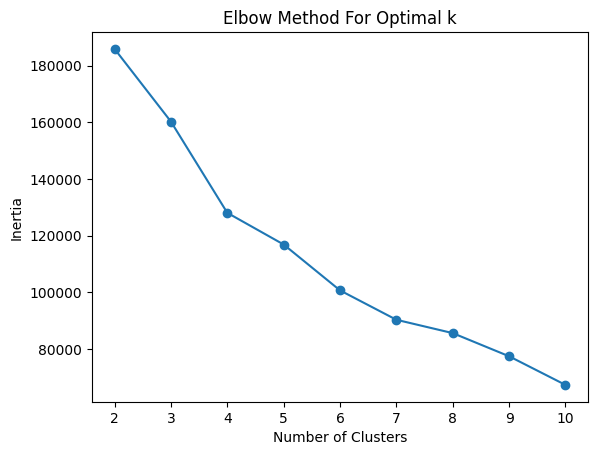

In [19]:
import matplotlib.pyplot as plt

inertia = []
K = range(2, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(features_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.show()


In [20]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans

# Step 0: Sample input (if needed for speed)
# df = df.sample(10000)

# Step 1: Select numeric + categorical features
numerical_cols = ['runtime', 'vote_average', 'vote_count', 'popularity_score', 'movie_age']
categorical_col = 'main_genre'

df_subset = df[numerical_cols + [categorical_col]].dropna()

# Step 2: One-hot encode 'main_genre'
ohe = OneHotEncoder(handle_unknown='ignore')
genre_encoded = ohe.fit_transform(df_subset[[categorical_col]])
genre_df = pd.DataFrame(genre_encoded.toarray(), columns=ohe.get_feature_names_out([categorical_col]), index=df_subset.index)

# genre_df = pd.DataFrame(genre_encoded, columns=ohe.get_feature_names_out([categorical_col]), index=df_subset.index)

# Step 3: Combine with numerical data
X_num = df_subset[numerical_cols]
X_full = pd.concat([X_num, genre_df], axis=1)

# Step 4: Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_full)

# Step 5: Cluster
kmeans = KMeans(n_clusters=5, random_state=42)
df.loc[df_subset.index, 'cluster'] = kmeans.fit_predict(X_scaled)

# Step 6: Inspect result
print(df[['title', 'main_genre', 'cluster']].head())


                         title main_genre  cluster
0                    Toy Story  Animation      1.0
1                      Jumanji  Adventure      4.0
2             Grumpier Old Men    Romance      1.0
3            Waiting to Exhale     Comedy      1.0
4  Father of the Bride Part II     Comedy      1.0


In [21]:
df["cluster"].unique()

array([ 1.,  4.,  2.,  3.,  0., nan])

In [22]:
for cluster in range(9):
    dfx = df.loc[df["cluster"] == cluster]
    

In [23]:
df.loc[df["cluster"] == 7]

,movieId,imdbId,tmdbId,imdb_id,title,original_language,overview,tagline,release_date,release_year,...,spoken_language_names,main_language,has_translation,production_country_names,main_country,production_company_names,main_production_company,company_popularity,franchise_strength,cluster


In [24]:
df.loc[df["cluster"].isna()]

,movieId,imdbId,tmdbId,imdb_id,title,original_language,overview,tagline,release_date,release_year,...,spoken_language_names,main_language,has_translation,production_country_names,main_country,production_company_names,main_production_company,company_popularity,franchise_strength,cluster
634,643,117312,287305,tt0117312,Peanuts – Die Bank zahlt alles,de,None,None,1996-03-21,1996.0,...,[],None,[],[Germany],Germany,[Westdeutscher Rundfunk (WDR)],Westdeutscher Rundfunk (WDR),0.141611,NaN,NaN
635,644,116485,339428,tt0116485,Happy Weekend,de,None,None,1996-03-14,1996.0,...,[Deutsch],Deutsch,[],[Germany],Germany,[Senator Film Produktion],Senator Film Produktion,0.154006,NaN,NaN
644,654,118026,278978,tt0118026,Und keiner weint mir nach,de,None,None,1996-02-29,1996.0,...,[Deutsch],Deutsch,[],[Germany],Germany,[],None,NaN,NaN,NaN
809,826,112865,282919,tt0112865,Diebinnen,de,None,None,1996-06-20,1996.0,...,[],None,[],[Germany],Germany,[],None,NaN,NaN,NaN
877,890,94822,253632,tt0094822,Baton Rouge,fr,None,None,1988-10-08,1988.0,...,[],None,[],[],None,[],None,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46739,175921,98035,369444,tt0098035,Ostatni dzwonek,pl,None,None,1989-10-27,1989.0,...,[],None,[],[Poland],Poland,[],None,NaN,NaN,NaN
46764,175985,1883368,335251,tt1883368,The Land Where the Blues Began,en,An exploration of the musical and social origi...,None,NaT,NaN,...,[],None,[],[],None,[],None,NaN,NaN,NaN
46803,176067,70695,317389,tt0070695,Simbad e il califfo di Bagdad,es,None,None,1973-07-22,1973.0,...,[Italiano],Italiano,[],[Italy],Italy,"[Roas Produzioni, Buton Film]",Roas Produzioni,0.123383,NaN,NaN
46836,176151,321264,449131,tt0321264,Aprel,ru,None,None,NaT,NaN,...,[],None,[],[Russia],Russia,[],None,NaN,NaN,NaN


In [25]:
feature_names = X_full.columns

# Get cluster centers (scaled)
cluster_centers = kmeans.cluster_centers_

# Convert back to readable format (unscaled)
unscaled_centers = StandardScaler().fit(X_full).inverse_transform(cluster_centers)

# Create DataFrame for easier inspection
centroids_df = pd.DataFrame(unscaled_centers, columns=feature_names)
centroids_df.index.name = 'cluster'


In [26]:
centroids_df

,runtime,vote_average,vote_count,popularity_score,movie_age,main_genre_(no genres listed),main_genre_Action,main_genre_Adventure,main_genre_Animation,main_genre_Children,...,main_genre_Music,main_genre_Musical,main_genre_Mystery,main_genre_Romance,main_genre_Sci-Fi,main_genre_Science Fiction,main_genre_TV Movie,main_genre_Thriller,main_genre_War,main_genre_Western
cluster,,,,,,,,,,,,,,,,,,,,,
0,94.273973,4.278767,304.173516,10.500990,58.189498,0.000000e+00,8.326673e-17,-1.387779e-17,3.469447e-18,-2.168404e-19,...,-6.938894e-18,5.421011e-20,-1.734723e-18,2.428613e-17,0.000000e+00,6.938894e-18,8.673617e-18,2.775558e-17,8.673617e-18,1.000000e+00
1,86.944746,4.341412,498.242416,13.466786,30.953240,6.010841e-02,-4.163336e-15,6.175616e-16,4.675997e-02,5.258474e-04,...,1.933501e-02,2.022490e-04,2.228784e-02,4.910606e-02,1.213494e-04,2.596877e-02,1.577542e-02,7.216245e-02,-2.046974e-16,-2.619432e-16
2,100.245068,4.234245,1054.958571,16.116225,31.736519,-4.857226e-17,9.997808e-01,3.330669e-16,-3.469447e-18,2.222614e-18,...,1.908196e-17,-2.981556e-19,-4.510281e-17,0.000000e+00,-3.252607e-19,8.500145e-17,1.561251e-17,2.192021e-04,0.000000e+00,-6.938894e-18
3,98.979792,4.488340,841.478060,15.489632,41.385104,3.469447e-17,-1.804112e-16,-1.387779e-17,5.898060e-17,5.421011e-19,...,1.734723e-17,1.355253e-19,2.602085e-17,-5.551115e-17,-2.439455e-19,6.938894e-18,1.561251e-17,-2.775558e-17,-1.561251e-17,-3.642919e-17
4,104.439871,4.426216,660.174247,14.554664,34.303560,5.488098e-04,-2.053913e-15,1.099678e-01,-6.487866e-16,-3.415237e-18,...,1.752071e-16,-2.981556e-18,3.816392e-17,-5.204170e-16,1.694066e-18,1.372024e-04,6.860122e-05,1.144917e-15,2.606846e-02,-1.439820e-16


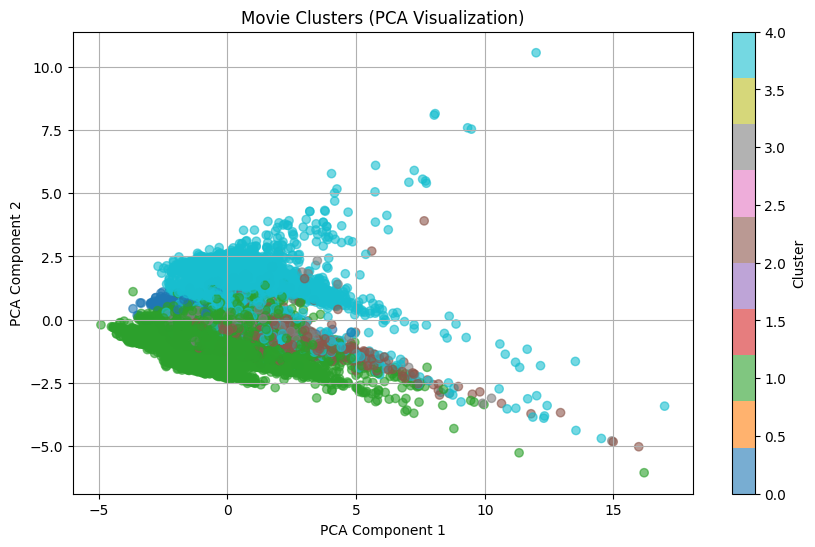

In [27]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce to 2 principal components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Add to DataFrame for plotting
df_plot = df.loc[df_subset.index].copy()
df_plot['pca_1'] = X_pca[:, 0]
df_plot['pca_2'] = X_pca[:, 1]

# Plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df_plot['pca_1'], df_plot['pca_2'],
    c=df_plot['cluster'], cmap='tab10', alpha=0.6
)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Movie Clusters (PCA Visualization)')
plt.colorbar(scatter, label='Cluster')
plt.grid(True)
plt.show()


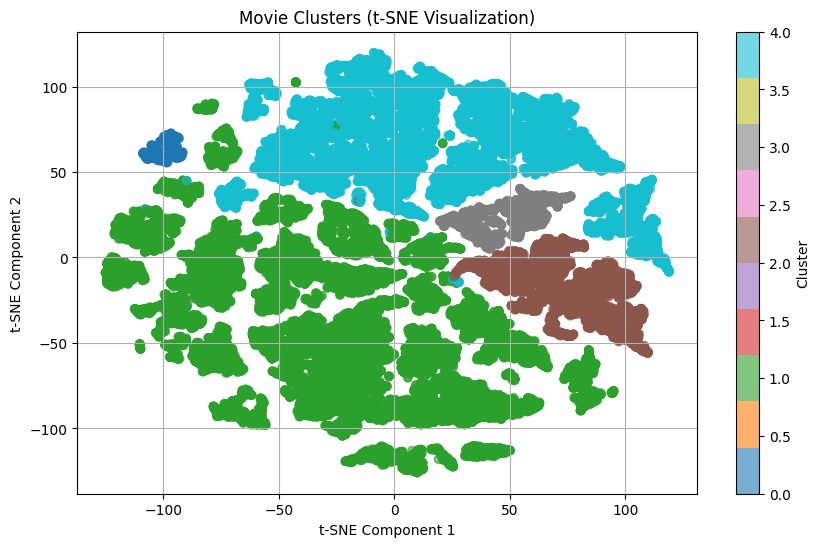

In [28]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

df_plot['tsne_1'] = X_tsne[:, 0]
df_plot['tsne_2'] = X_tsne[:, 1]

# Plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df_plot['tsne_1'], df_plot['tsne_2'],
    c=df_plot['cluster'], cmap='tab10', alpha=0.6
)
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('Movie Clusters (t-SNE Visualization)')
plt.colorbar(scatter, label='Cluster')
plt.grid(True)
plt.show()


In [29]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Step 1: Assume X_full is your final feature set (numeric + one-hot genre)
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_full)

# Step 2: Run DBSCAN
db = DBSCAN(eps=1.5, min_samples=10)  # You can tune these!
db_labels = db.fit_predict(X_scaled)

# Step 3: Attach labels to your DataFrame
df.loc[df_subset.index, 'db_cluster'] = db_labels


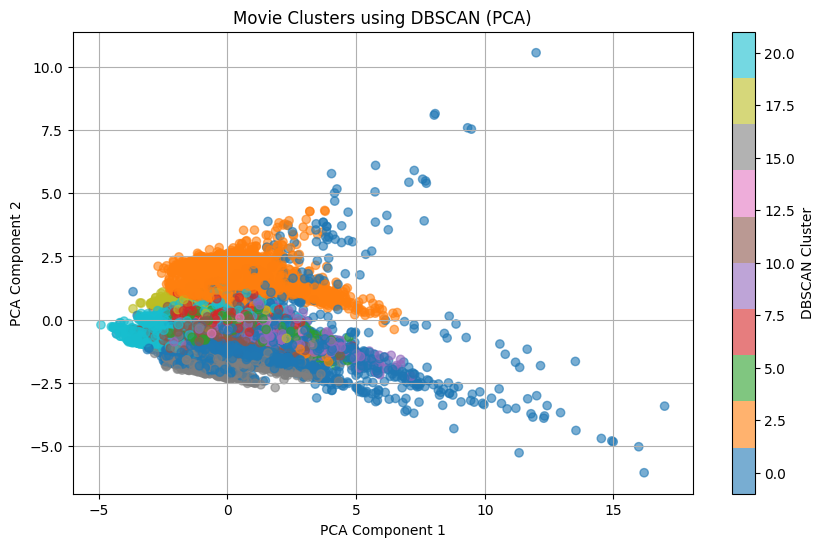

In [30]:
# PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot
df_plot = df.loc[df_subset.index].copy()
df_plot['pca_1'] = X_pca[:, 0]
df_plot['pca_2'] = X_pca[:, 1]
df_plot['db_cluster'] = db_labels

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df_plot['pca_1'],
    df_plot['pca_2'],
    c=df_plot['db_cluster'],
    cmap='tab10',
    alpha=0.6
)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Movie Clusters using DBSCAN (PCA)')
plt.colorbar(scatter, label='DBSCAN Cluster')
plt.grid(True)
plt.show()


In [31]:
from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Step 1: Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_full)

# Step 2: DBSCAN clustering
dbscan = DBSCAN(eps=1.5, min_samples=10)  # Tune these!
db_labels = dbscan.fit_predict(X_scaled)

# Step 3: t-SNE dimensionality reduction
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

# Step 4: Create plot DataFrame
df_tsne = df.loc[df_subset.index].copy()
df_tsne['tsne_1'] = X_tsne[:, 0]
df_tsne['tsne_2'] = X_tsne[:, 1]
df_tsne['db_cluster'] = db_labels


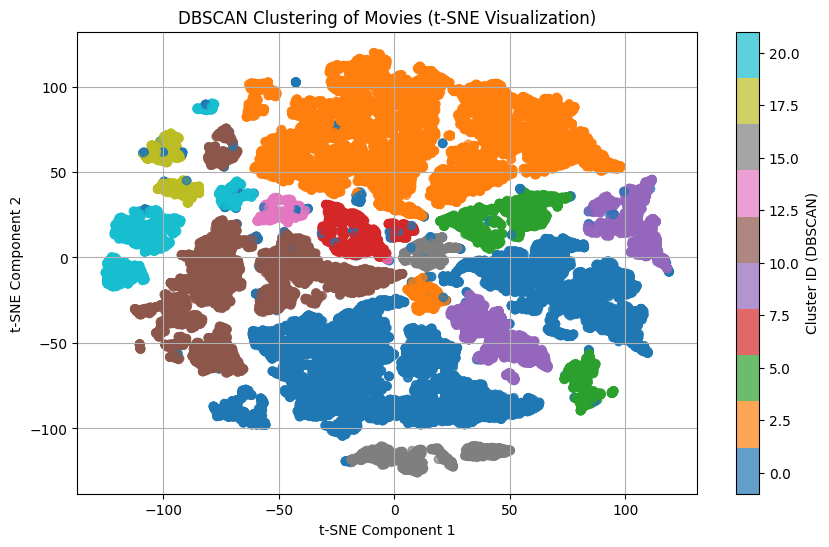

In [32]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df_tsne['tsne_1'], df_tsne['tsne_2'],
    c=df_tsne['db_cluster'], cmap='tab10', alpha=0.7
)
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('DBSCAN Clustering of Movies (t-SNE Visualization)')
plt.colorbar(scatter, label='Cluster ID (DBSCAN)')
plt.grid(True)
plt.show()


In [42]:
user_df = pd.read_csv("/Users/aniket/TU_Eindhoven/2_Study/Q4_2AMV10_Visual_Analytics/4_Code/2_AMV10_Visual_Analytics/selected_users_rating_data.csv")  # or your existing DataFrame

In [43]:
user_df["userId"].unique()

array([    34,      7, 283197, 123100])

In [44]:
user_df = user_df.loc[user_df["userId"] != 123100]

In [45]:
# Sample user ratings structure
# Columns expected: userId, movieId, rating
# Make sure 'movieId' and 'db_cluster' exist in df
movie_clusters = df[['movieId', 'title', 'db_cluster']].dropna()

# Merge user ratings with movie clusters
user_ratings_with_clusters = user_df.merge(movie_clusters, on='movieId', how='inner')

user_id = 34  # example user ID

user_cluster_counts = (
    user_ratings_with_clusters[user_ratings_with_clusters['userId'] == user_id]
    .groupby('db_cluster')
    .size()
    .sort_values(ascending=False)
)

print(f"User {user_id} rated movies from these clusters:")
print(user_cluster_counts)


User 34 rated movies from these clusters:
db_cluster
-1.0     26
 3.0     24
 0.0     10
 1.0      9
 8.0      7
 16.0     4
 4.0      2
 5.0      2
 15.0     2
 6.0      1
 14.0     1
dtype: int64


In [46]:
user_cluster_summary = (
    user_ratings_with_clusters
    .groupby(['userId', 'db_cluster'])
    .size()
    .reset_index(name='num_rated')
    .sort_values(['userId', 'num_rated'], ascending=[True, False])
)

# View top 5 users and their preferences
print(user_cluster_summary.head())


   userId  db_cluster  num_rated
1       7         3.0          7
2       7         4.0          2
0       7         1.0          1
3       7         5.0          1
4       7         7.0          1


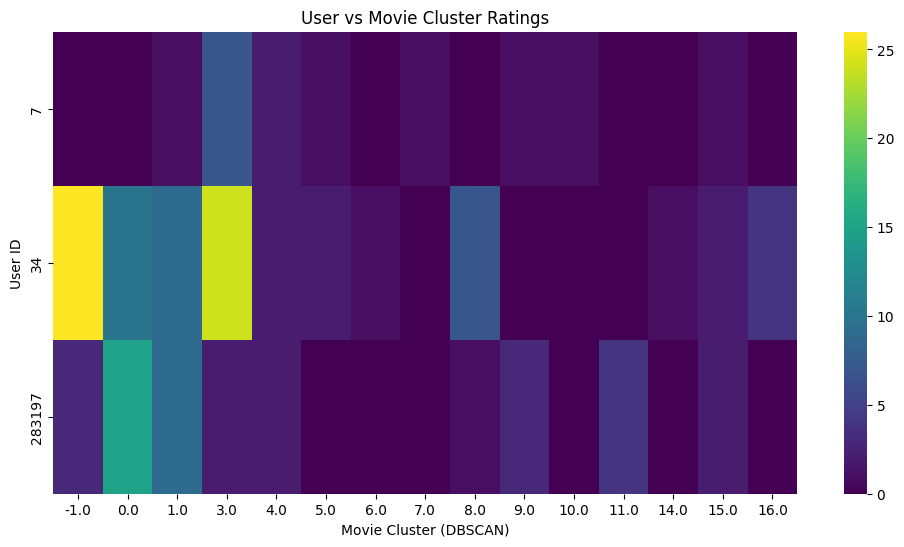

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pivot to wide format
heatmap_data = user_cluster_summary.pivot(index='userId', columns='db_cluster', values='num_rated').fillna(0)

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap='viridis')
plt.title('User vs Movie Cluster Ratings')
plt.xlabel('Movie Cluster (DBSCAN)')
plt.ylabel('User ID')
plt.show()
